# Figure 7i: Cumulative integrated CO2 flux

Plots the cumulative integral of the net CO2 flux from 90S to 30S (in
PgC/yr). The cell area is computed manually for lat-lon models, as some
models use a different grid for `areacello` and `fgco2`.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

This integrates the flux of Figure 7h from the South Pole northwards, so
the value at any latitude is the total carbon uptake south of that
latitude, and the value at 30S is the Southern Ocean total.

The shape of the curve is as informative as its endpoint: a curve that
falls and then rises reflects the outgassing band near Antarctica
followed by the uptake band further north. Models reaching similar
totals may do so along very different paths.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
# Constants used by the original NCL scripts
EARTH_RADIUS = 6.37e06   # m
DEG2RAD = 0.0174533


_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_DASHES = ["-", "--", "-.", ":"]
_MARKERS = ["o", "s", "D", "^", "v", "P", "X", "*"]


def style_for(index):
    """Line and marker style for the index-th dataset."""
    return {
        "color": _COLORS[index % len(_COLORS)],
        "dash": _DASHES[index % len(_DASHES)],
        "thick": 1.5,
        "mark": _MARKERS[index % len(_MARKERS)],
    }


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def has_regular_grid(cube):
    """True if the cube has 1D latitude and longitude coordinates."""
    return (cube.coord("latitude").ndim == 1
            and cube.coord("longitude").ndim == 1)


def lat_1d(cube):
    """A representative 1D latitude array (column 0 for 2D grids)."""
    lat = coord_1d_or_2d(cube, "latitude")
    return lat[:, 0] if lat.ndim == 2 else lat


def lon_1d(cube):
    """A representative 1D longitude array (row 0 for 2D grids)."""
    lon = coord_1d_or_2d(cube, "longitude")
    return lon[0, :] if lon.ndim == 2 else lon


def ncl_cell_area(lat, lon, shape):
    """Cell areas of a regular lat-lon grid, as computed in NCL.

    Replicates the manual areacello calculation of the NCL scripts:
    a constant dlat/dlon taken from grid points 19 and 20, then
    area = dx * dy with dx = R cos(lat) dlon and dy = R dlat.
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    dlat = abs(lat[20] - lat[19])
    dlon = abs(lon[20] - lon[19])
    dx = dlon * EARTH_RADIUS * DEG2RAD * np.cos(lat * DEG2RAD)
    dy = dlat * EARTH_RADIUS * DEG2RAD
    return np.broadcast_to((dx * dy)[:, np.newaxis], shape)

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36855 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36855/status,
Dashboard: /proxy/36855/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43073,Workers: 0
Dashboard: /proxy/36855/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39141,Total threads: 2
Dashboard: /proxy/41043/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:41883,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

fgco2_datasets = {
    "CanESM2": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2M": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2M",
        timerange="19860101/20051231",
    ),
    "MRI-ESM1": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="MRI-ESM1",
        timerange="19860101/20051231",
    ),
}

areacello_datasets = {
    "CanESM2": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2M": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="GFDL-ESM2M",
        timerange="19860101/20051231",
    ),
    "MRI-ESM1": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="MRI-ESM1",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Supplementary (ancillary) variables

`mask_landsea` needs a land/sea fraction field.  Without one it falls
back to Natural Earth shapefiles, which only work on **regular
lat-lon grids**; on the curvilinear ocean grids used by most CMIP5
ocean variables it raises

    ValueError: Use of shapefiles with irregular grids not yet
    implemented, land-sea mask not applied.

When running the recipe, ESMValTool attaches these automatically - in a
notebook they have to be added explicitly.  `mask_landsea` looks for
`sftlf` (land fraction) first and then `sftof` (sea fraction).  Note
that CMIP5 fx variables use the `r0i0p0` ensemble.

In [5]:
for dataset in fgco2_datasets.values():
    dataset.add_supplementary(short_name="sftof", mip="fx", ensemble="r0i0p0")

# A few models publish only the other mask (the recipe does
# this for MIROC-ESM); uncomment if one of yours is missing:
# dataset.add_supplementary(short_name="sftlf", mip="fx", ensemble="r0i0p0")

## Preprocessing

`climate_statistics` takes the full-period time mean and
`mask_landsea` removes the land points, as the
`preprocessor_time_land` preprocessor of the recipe does.

If a model publishes neither `sftlf` nor `sftof`, the land mask is
skipped with a message rather than failing: ocean variables are
already undefined over land in the source files, so the figure is
still correct.

In [6]:
from esmvalcore.preprocessor import (
    climate_statistics,
    mask_landsea,
)


def preprocess(cube):
    """Time mean + land mask (preprocessor_time_land)."""
    try:
        cube = mask_landsea(cube, mask_out="land")
    except ValueError as exc:
        # no sftlf/sftof for this model and an irregular
        # grid: ocean variables are already undefined over
        # land in the source files, so carry on unmasked
        print(f"  land mask skipped: {exc}")
    return climate_statistics(cube, operator="mean", period="full")


fgco2_cubes = {name: preprocess(dataset.load()) for name, dataset in fgco2_datasets.items()}
areacello_cubes = {name: dataset.load() for name, dataset in areacello_datasets.items()}

fgco2_cubes

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
 fgco2: attribute positive not present
loaded from file 
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rule

{'CanESM2': <iris 'Cube' of surface_downward_mass_flux_of_carbon_dioxide_expressed_as_carbon / (kg m-2 s-1) (latitude: 192; longitude: 256)>,
 'GFDL-ESM2M': <iris 'Cube' of surface_downward_mass_flux_of_carbon_dioxide_expressed_as_carbon / (kg m-2 s-1) (grid_latitude: 200; grid_longitude: 360)>,
 'MRI-ESM1': <iris 'Cube' of surface_downward_mass_flux_of_carbon_dioxide_expressed_as_carbon / (kg m-2 s-1) (grid_latitude: 368; grid_longitude: 360)>}

## Diagnostic

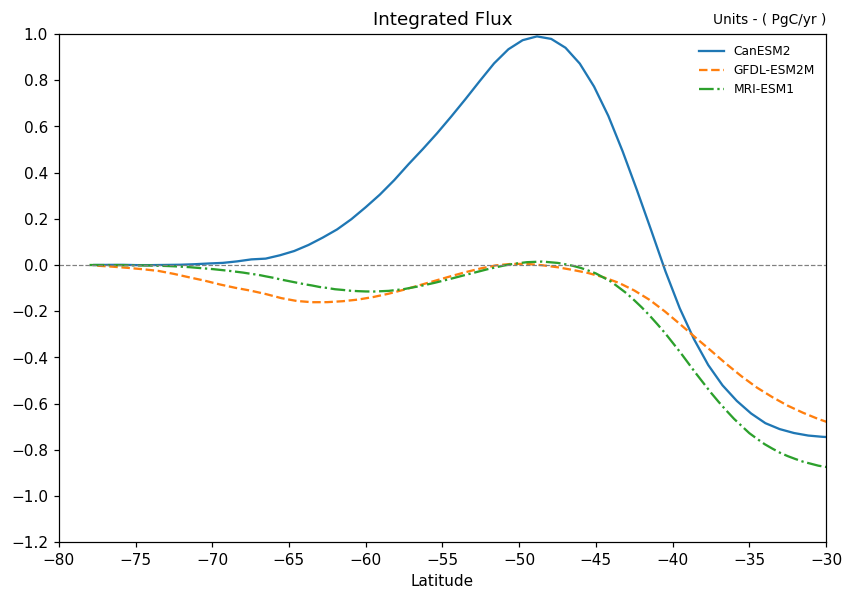

In [7]:
UNIT_FACTOR = -0.000031536   # kg s-1 -> PgC yr-1 (sea-to-air)

fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, cube) in enumerate(fgco2_cubes.items()):
    data = np.ma.masked_invalid(cube.data)
    lat = lat_1d(cube)
    if has_regular_grid(cube):
        area = ncl_cell_area(lat, lon_1d(cube), data.shape)
    else:
        area = np.ma.masked_invalid(areacello_cubes[name].data)

    # flux per cell -> flux per latitude -> cumulative sum from 90S
    cumulative = np.ma.cumsum((data * UNIT_FACTOR * area).sum(axis=-1))

    style = style_for(i)
    ax.plot(lat, cumulative, label=name, color=style["color"],
            linestyle=style["dash"], linewidth=style["thick"])

ax.set_xlim(-80, -30)
ax.set_ylim(-1.2, 1.0)
ax.set_xticks(np.arange(-80, -29, 5))
ax.set_yticks(np.arange(-1.2, 1.01, 0.2))
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Latitude")
ax.set_title("Integrated Flux")
ax.text(1.0, 1.02, "Units - ( PgC/yr )", ha="right",
        transform=ax.transAxes, fontsize=9)
ax.legend(fontsize=8, frameon=False)
plt.show()

**Figure 7i: Cumulative integrated CO2 flux:** Cumulative integral of the net sea-to-air CO2 flux from 90S northwards
(PgC/yr).